# IntenCite - Baseline TF-IDF + Logistic Regression + MLflow

Primera línea base reproducible para clasificar la función semántica de una cita académica en cinco clases:

- Background
- Gap
- Application
- Improvement
- Comparison

El objetivo de esta versión es tener un flujo completo y sencillo:

**datos versionados → split oficial → entrenamiento → evaluación → probabilidades → registro en MLflow**

## 1. Configuración

In [3]:
from pathlib import Path
import json
import tempfile

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline

SEED = 42

# Detectar la raíz del repositorio aunque el notebook se ejecute
# desde notebooks/experiments o desde la raíz.
cwd = Path.cwd()
if cwd.name == "experiments":
    ROOT = cwd.parent.parent
elif cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

DATA_PATH = ROOT / "data" / "multicite_3ctx_balanceado.csv"

TEXT_COL = "context"
LABEL_COL = "label_proyecto"
SPLIT_COL = "split_proyecto"
GROUP_COL = "pair_id"

# MLflow
USE_MLFLOW = True
MLFLOW_TRACKING_URI = "http://127.0.0.1:8050" #"http://<EC2_PUBLIC_IP>:8050"
MLFLOW_EXPERIMENT = "intencite-model-comparison"
RUN_NAME = "tfidf-logreg-baseline-v1"

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)

ROOT: /home/jmalaver/projects/MLOps/mini-project/citation-recommendation-nlp
DATA_PATH: /home/jmalaver/projects/MLOps/mini-project/citation-recommendation-nlp/data/multicite_3ctx_balanceado.csv


## 2. Carga y validación del dataset

Se utiliza directamente la partición oficial almacenada en `split_proyecto`.

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No encontré {DATA_PATH}. Ejecuta `uv run dvc pull` desde la raíz del repositorio."
    )

df = pd.read_csv(DATA_PATH)

required = {TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas obligatorias: {missing}")

model_df = df.dropna(subset=[TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL]).copy()
model_df[TEXT_COL] = model_df[TEXT_COL].astype(str)
model_df[LABEL_COL] = model_df[LABEL_COL].astype(str)

print("Shape:", model_df.shape)
print("\nSplits:")
print(model_df[SPLIT_COL].value_counts())
print("\nClases:")
print(model_df[LABEL_COL].value_counts())

Shape: (3491, 9)

Splits:
split_proyecto
train    2491
test      517
val       483
Name: count, dtype: int64

Clases:
label_proyecto
Gap            700
Comparison     700
Application    700
Background     700
Improvement    691
Name: count, dtype: int64


## 3. Particiones oficiales y control de leakage

In [5]:
train_df = model_df[model_df[SPLIT_COL] == "train"].copy()
val_df = model_df[model_df[SPLIT_COL] == "val"].copy()
test_df = model_df[model_df[SPLIT_COL] == "test"].copy()

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_pairs = set(train_df[GROUP_COL])
val_pairs = set(val_df[GROUP_COL])
test_pairs = set(test_df[GROUP_COL])

assert train_pairs.isdisjoint(val_pairs)
assert train_pairs.isdisjoint(test_pairs)
assert val_pairs.isdisjoint(test_pairs)

print("OK: cero solapamiento de pair_id entre train, val y test.")

Train: 2491
Val: 483
Test: 517
OK: cero solapamiento de pair_id entre train, val y test.


## 4. Baseline TF-IDF + Logistic Regression

Esta primera versión es deliberadamente simple y sirve como referencia para comparar
experimentos posteriores.

In [6]:
baseline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            max_features=50_000,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=SEED,
        ),
    ),
])

baseline.fit(train_df[TEXT_COL], train_df[LABEL_COL])
print("Modelo entrenado.")

Modelo entrenado.


## 5. Función de evaluación

In [7]:
def evaluate(model, frame):
    y_true = frame[LABEL_COL]
    y_pred = model.predict(frame[TEXT_COL])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
    }

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    return metrics, y_pred, report

## 6. Evaluación en validación

El conjunto de validación se utiliza para comparar versiones y ajustar decisiones.
El conjunto de test se reserva para la evaluación final del modelo seleccionado.

In [8]:
val_metrics, val_pred, val_report = evaluate(baseline, val_df)

print(json.dumps(val_metrics, indent=2))
print()
print(
    classification_report(
        val_df[LABEL_COL],
        val_pred,
        zero_division=0,
    )
)

{
  "accuracy": 0.5134575569358178,
  "precision_macro": 0.5150368964790217,
  "recall_macro": 0.5128429302533304,
  "f1_macro": 0.5124938602593829,
  "f1_micro": 0.5134575569358178
}

              precision    recall  f1-score   support

 Application       0.60      0.53      0.56       102
  Background       0.44      0.54      0.49        89
  Comparison       0.55      0.52      0.53       108
         Gap       0.43      0.43      0.43        91
 Improvement       0.55      0.55      0.55        93

    accuracy                           0.51       483
   macro avg       0.52      0.51      0.51       483
weighted avg       0.52      0.51      0.51       483



## 7. Matriz de confusión de validación

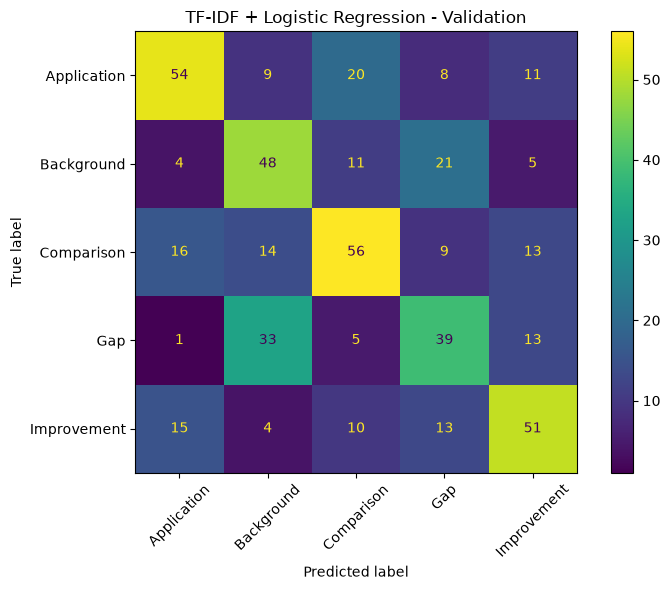

In [9]:
classes = list(baseline.named_steps["classifier"].classes_)

cm = confusion_matrix(
    val_df[LABEL_COL],
    val_pred,
    labels=classes,
)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes,
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)

ax.set_title("TF-IDF + Logistic Regression - Validation")
plt.tight_layout()
plt.show()

## 8. Registro del baseline en MLflow

Para la entrega, reemplaza `<EC2_PUBLIC_IP>` por la IP pública de la EC2 donde esté ejecutándose
el servidor de MLflow.

Cada modelo o configuración debe registrarse como una **run distinta**, pero todos pueden usar el
mismo experimento `intencite-model-comparison`.

In [10]:
if USE_MLFLOW:
    if "<EC2_PUBLIC_IP>" in MLFLOW_TRACKING_URI:
        raise ValueError(
            "Reemplaza <EC2_PUBLIC_IP> en MLFLOW_TRACKING_URI antes de registrar en MLflow."
        )

    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    tfidf = baseline.named_steps["tfidf"]
    clf = baseline.named_steps["classifier"]

    with mlflow.start_run(run_name=RUN_NAME) as run:
        # Parámetros
        mlflow.log_params({
            "model_type": "LogisticRegression",
            "vectorizer": "TfidfVectorizer",
            "ngram_range": str(tfidf.ngram_range),
            "min_df": tfidf.min_df,
            "max_df": tfidf.max_df,
            "max_features": tfidf.max_features,
            "sublinear_tf": tfidf.sublinear_tf,
            "max_iter": clf.max_iter,
            "random_state": SEED,
            "text_column": TEXT_COL,
            "label_column": LABEL_COL,
            "split_column": SPLIT_COL,
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "test_rows": len(test_df),
        })

        # Métricas
        mlflow.log_metrics({
            f"val_{name}": float(value)
            for name, value in val_metrics.items()
        })

        # Tags útiles para comparar corridas
        mlflow.set_tags({
            "project": "IntenCite",
            "stage": "baseline",
            "model_family": "classical_ml",
            "dataset": "multicite_3ctx_proyecto",
        })

        # Artifacts
        with tempfile.TemporaryDirectory() as tmp:
            tmp = Path(tmp)

            # Classification report
            report_path = tmp / "classification_report_validation.json"
            report_path.write_text(
                json.dumps(val_report, indent=2),
                encoding="utf-8",
            )
            mlflow.log_artifact(str(report_path), artifact_path="evaluation")

            # Matriz de confusión
            cm_path = tmp / "confusion_matrix_validation.png"

            fig, ax = plt.subplots(figsize=(8, 6))
            ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=classes,
            ).plot(
                ax=ax,
                xticks_rotation=45,
                values_format="d",
            )
            ax.set_title("TF-IDF + Logistic Regression - Validation")
            plt.tight_layout()
            fig.savefig(cm_path, dpi=160, bbox_inches="tight")
            plt.close(fig)

            mlflow.log_artifact(str(cm_path), artifact_path="evaluation")

            # Copia serializada sencilla del pipeline
            model_path = tmp / "tfidf_logreg_pipeline.joblib"
            joblib.dump(baseline, model_path)
            mlflow.log_artifact(str(model_path), artifact_path="model_artifact")

        # Modelo en formato MLflow
        mlflow.sklearn.log_model(
            sk_model=baseline,
            artifact_path="model",
        )

        print("MLflow run ID:", run.info.run_id)
        print("Experiment:", MLFLOW_EXPERIMENT)
        print("Run:", RUN_NAME)
else:
    print("USE_MLFLOW=False: no se registró ninguna corrida.")

2026/09/02 00:40:21 INFO mlflow.tracking.fluent: Experiment with name 'intencite-model-comparison' does not exist. Creating a new experiment.
2026/09/02 00:40:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/02 00:42:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLflow run ID: b1970bab9dd3462eb151bb322e07f1fa
Experiment: intencite-model-comparison
Run: tfidf-logreg-baseline-v1
🏃 View run tfidf-logreg-baseline-v1 at: http://127.0.0.1:8050/#/experiments/1/runs/b1970bab9dd3462eb151bb322e07f1fa
🧪 View experiment at: http://127.0.0.1:8050/#/experiments/1


## 9. Probabilidades por clase

El baseline entrega una distribución de probabilidad sobre las cinco categorías.
Esta salida puede utilizarse más adelante desde la API y el tablero.

In [11]:
sample = val_df[[TEXT_COL, LABEL_COL]].head(10).copy()

probabilities = baseline.predict_proba(sample[TEXT_COL])
classes = baseline.named_steps["classifier"].classes_

prob_df = pd.DataFrame(
    probabilities,
    columns=[f"prob_{c}" for c in classes],
    index=sample.index,
)

result = pd.concat(
    [
        sample,
        pd.Series(
            baseline.predict(sample[TEXT_COL]),
            index=sample.index,
            name="prediction",
        ),
        prob_df,
    ],
    axis=1,
)

display(result)

,context,label_proyecto,prediction,prob_Application,prob_Background,prob_Comparison,prob_Gap,prob_Improvement
12,"<cite>(Gliozzo et al., 2005)</cite> succeeded ...",Gap,Improvement,0.229945,0.221836,0.138819,0.162272,0.247128
13,When analyzing the behavior of the LSA represe...,Gap,Gap,0.127064,0.195525,0.170320,0.304799,0.202291
38,The aforementioned deficiencies prompt researc...,Background,Background,0.076884,0.385501,0.109680,0.267633,0.160302
39,In the presence of the success of pre-trained ...,Gap,Background,0.071903,0.295449,0.188823,0.244614,0.199212
41,**CONCLUSION** The work provides preliminary r...,Comparison,Improvement,0.148394,0.208993,0.201511,0.198105,0.242997
67,**INTRODUCTION** Self-training methods such as...,Gap,Background,0.116057,0.325503,0.163795,0.251996,0.142649
68,"Training is computationally expensive, limitin...",Improvement,Improvement,0.155973,0.138072,0.221445,0.232414,0.252097
69,The GLUE organizers provide training and devel...,Application,Application,0.351892,0.091901,0.148899,0.128203,0.279105
70,"To better understand this discrepancy, we comp...",Application,Improvement,0.189089,0.198787,0.187596,0.188981,0.235545
71,We remove the NSP loss. Results Table 2 shows ...,Application,Application,0.321768,0.100196,0.222003,0.087056,0.268976


## 10. Función simple de inferencia

In [12]:
def predict_citation_function(text: str) -> dict:
    probs = baseline.predict_proba([text])[0]
    pred = baseline.predict([text])[0]
    classes = baseline.named_steps["classifier"].classes_

    return {
        "prediction": pred,
        "probabilities": {
            cls: float(prob)
            for cls, prob in zip(classes, probs)
        },
    }

example_text = (
    "Previous work <cite> introduced a similar method for citation intent classification, "
    "which we use as the basis of our experimental setup."
)

predict_citation_function(example_text)

{'prediction': 'Application',
 'probabilities': {'Application': 0.35693494563604106,
  'Background': 0.09593507992083591,
  'Comparison': 0.1784484153314265,
  'Gap': 0.13925586086620143,
  'Improvement': 0.22942569824549508}}

## 11. Test final

**No usar esta sección para elegir hiperparámetros.**
El conjunto de test debe evaluarse al final, cuando ya se haya seleccionado la mejor alternativa
utilizando validación.

In [13]:
RUN_FINAL_TEST = False

if RUN_FINAL_TEST:
    test_metrics, test_pred, test_report = evaluate(baseline, test_df)

    print(json.dumps(test_metrics, indent=2))
    print()
    print(
        classification_report(
            test_df[LABEL_COL],
            test_pred,
            zero_division=0,
        )
    )
else:
    print("Test reservado. Cambia RUN_FINAL_TEST=True únicamente para la evaluación final.")

Test reservado. Cambia RUN_FINAL_TEST=True únicamente para la evaluación final.
